# 04. Alkaline Oxygen Evolution Reaction

The alkaline associative 4-electron oxygen evolution reaction comprises four
electron transfers and one purely chemical proton-transfer step. Anodic is defined as 
forward (`direction=+1`). It is the anodic counterpart of the ORR
notebook and reaches the same conclusion by a different route.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import core          # parameterized microkinetics engine (the methods)
import mechanisms as M   # the mechanisms and designed-RLS cases of the paper

## The mechanism

$$1.\;\mathrm{M}+\mathrm{OH^-}\rightleftharpoons \mathrm{MOH}+e^-\;\;\text{(ET1)}$$
$$2.\;\mathrm{MOH}+\mathrm{OH^-}\rightleftharpoons \mathrm{MO}+\mathrm{H_2O}+e^-\;\;\text{(ET2)}$$
$$3.\;\mathrm{MO}+\mathrm{OH^-}\rightleftharpoons \mathrm{MOOH}+e^-\;\;\text{(ET3)}$$
$$4.\;\mathrm{MOOH}+\mathrm{OH^-}\rightleftharpoons \mathrm{MOO^-}+\mathrm{H_2O}\;\;\text{(ChemPT, chemical)}$$
$$5.\;\mathrm{MOO^-}\rightleftharpoons \mathrm{M}+\mathrm{O_2}+e^-\;\;\text{(ET4)}$$

Overall $4\,\mathrm{OH^-}\rightleftharpoons \mathrm{O_2}+2\,\mathrm{H_2O}+4e^-$ 
with unit activities. `M.oer_case(rls)` reconstructs the paper's cardinal
landscapes: steps upstream of the RLS are made uphill ($K=0.01$) so that the
RLS reactant remains unsaturated into the anodic window, downstream steps
absorb the balance so that $\prod K_i=1$, and the RLS forward constant is slow.
The methods are demonstrated on the ET2 case.

In [2]:
mech = M.oer_case("ET2")
print("species:", mech.species)
print("steps:  ", mech.labels)
print("landscape K_i:", M.OER_LANDSCAPES["ET2"])

species: ['M', 'MOH', 'MO', 'MOOH', 'MOOm']
steps:   ['ET1', 'ET2', 'ET3', 'ChemPT', 'ET4']
landscape K_i: [0.01, 1.0, 4.6416, 4.6416, 4.6416]


## Numerical integration to steady state

The coverage equations are integrated from a clean surface until they settle.


In [3]:
etas_coarse = np.linspace(0.004, 0.55, 12)
eta_n, j_n, th_n, b_n = core.numerical_scan(mech, etas_coarse)

print(f"{'eta/V':>8}{'j/A cm^-2':>14}{'b/mV dec^-1':>13}   coverages")
for e, jj, th, b in zip(eta_n, j_n, th_n, b_n):
    cov = "  ".join(f"{s}={t:6.3f}" for s, t in zip(mech.species, th))
    print(f"{e:8.3f}{jj:14.3e}{b:13.1f}   {cov}")

   eta/V     j/A cm^-2  b/mV dec^-1   coverages
   0.004     1.816e-09         10.7   M= 0.804  MOH= 0.009  MO= 0.006  MOOH= 0.032  MOOm= 0.148
   0.054     7.934e-08         40.6   M= 0.898  MOH= 0.072  MO= 0.000  MOOH= 0.005  MOOm= 0.024
   0.103     1.023e-06         51.8   M= 0.638  MOH= 0.355  MO= 0.000  MOOH= 0.003  MOOm= 0.003
   0.153     5.896e-06         85.0   M= 0.204  MOH= 0.779  MO= 0.001  MOOH= 0.015  MOOm= 0.001
   0.203     1.820e-05        115.7   M= 0.035  MOH= 0.915  MO= 0.001  MOOH= 0.047  MOOm= 0.001
   0.252     4.565e-05        132.8   M= 0.006  MOH= 0.874  MO= 0.001  MOOH= 0.118  MOOm= 0.001
   0.302     1.009e-04        160.0   M= 0.001  MOH= 0.736  MO= 0.001  MOOH= 0.262  MOOm= 0.001
   0.351     1.861e-04        228.4   M= 0.001  MOH= 0.516  MO= 0.001  MOOH= 0.482  MOOm= 0.001
   0.401     2.739e-04        407.5   M= 0.000  MOH= 0.289  MO= 0.000  MOOH= 0.710  MOOm= 0.000
   0.451     3.340e-04        877.9   M= 0.000  MOH= 0.134  MO= 0.000  MOOH= 0.865  MOOm

## Quasi-steady-state approximation

The same steady state is obtained by solving $N\,v(\theta)=0$ with a root
finder, seeded by continuation from the previous overpotential.

In [4]:
etas_dense = np.linspace(0.004, 0.55, 160)
eta_q, j_q, th_q, b_q = core.qssa_scan(mech, etas_dense)

# agreement at the coarse points (QSSA evaluated exactly there)
j_q_at = np.array([core.qssa_state(mech, e)[0] for e in eta_n])
print("max relative |j_QSSA - j_num| at the coarse points:",
      np.max(np.abs((j_q_at - j_n) / j_n)))

max relative |j_QSSA - j_num| at the coarse points: 1.474934706507431e-12


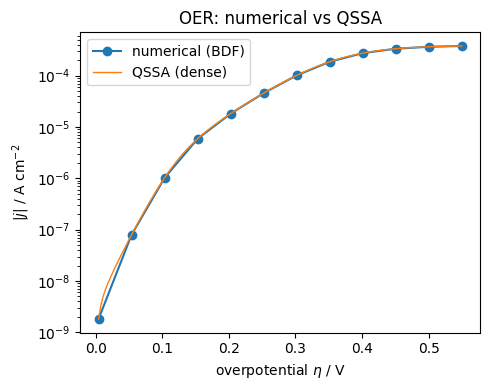

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.semilogy(eta_n, np.abs(j_n), "o-", label="numerical (BDF)")
ax.semilogy(eta_q, np.abs(j_q), "-", lw=1, label="QSSA (dense)")
ax.set_xlabel(r"overpotential $\eta$ / V")
ax.set_ylabel(r"$|j|$ / A cm$^{-2}$")
ax.legend(); ax.set_title("OER: numerical vs QSSA")
fig.tight_layout(); plt.show()

## Stochastic simulation (Gillespie Monte Carlo)

The method is identical to previous notebooks.

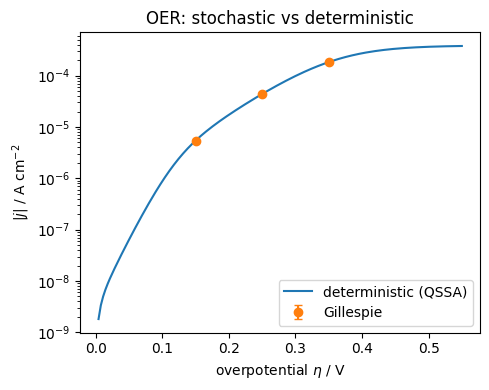

eta=+0.150 V   j= 5.296e-06 +/- 2.6e-07 A/cm^2
eta=+0.250 V   j= 4.433e-05 +/- 2.0e-07 A/cm^2
eta=+0.350 V   j= 1.836e-04 +/- 8.8e-07 A/cm^2


In [6]:
etas_gmc = np.array([0.15, 0.25, 0.35])
eg, jg, seg, thg = core.gillespie_scan(mech, etas_gmc,
                                       n_sites=1000, n_burn=20000, n_prod=80000, n_traj=3)

fig, ax = plt.subplots(figsize=(5, 4))
ax.semilogy(eta_q, np.abs(j_q), "-", label="deterministic (QSSA)")
ax.errorbar(eg, np.abs(jg), yerr=seg, fmt="o", capsize=3, label="Gillespie")
ax.set_xlabel(r"overpotential $\eta$ / V")
ax.set_ylabel(r"$|j|$ / A cm$^{-2}$")
ax.legend(); ax.set_title("OER: stochastic vs deterministic")
fig.tight_layout(); plt.show()

for e, jj, s in zip(eg, jg, seg):
    print(f"eta={e:+.3f} V   j={jj: .3e} +/- {s:.1e} A/cm^2")

## Potentiostatic transients

As in the ORR notebook, the early-time current is carried by the fast steps
loading the surface before the steady cycle takes over. The right panel
enlarges the early-time window.

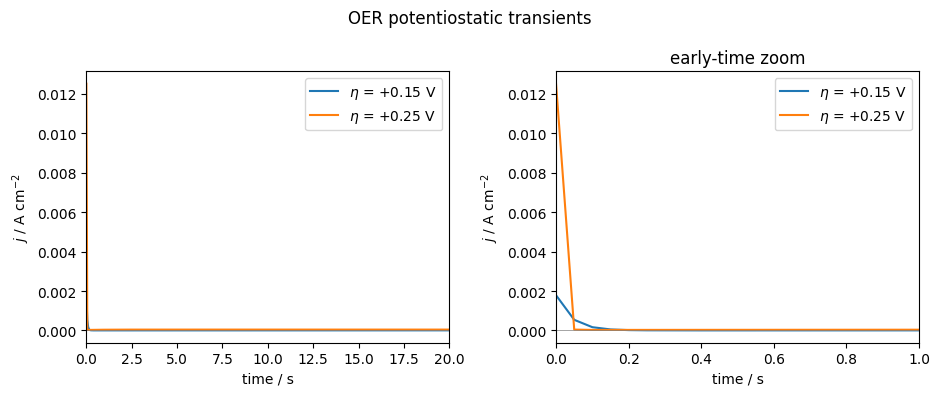

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for e in (0.15, 0.25):
    t, it = core.transient(mech, e, t_end=20.0, n=400)
    for ax in axes:
        ax.plot(t, it, label=fr"$\eta$ = {e:+.2f} V")
axes[0].set_xlim(0, 20.0); axes[1].set_xlim(0, 1.0)   # full window and early zoom
for ax in axes:
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel("time / s"); ax.set_ylabel(r"$j$ / A cm$^{-2}$"); ax.legend()
axes[1].set_title("early-time zoom")
fig.suptitle("OER potentiostatic transients")
fig.tight_layout(); plt.show()

## Five cardinal landscapes

One case per RLS (ET1 / ET2 / ET3 / ChemPT / ET4). Three regimes appear in the
local-slope panel. Near onset the electron-transfer cases show the cardinal
ladder (120/40/24/17 mV/dec) and the chemical case saturates. By
$\eta \approx +0.2$ V the RLS reactants saturate and the electron-transfer
cases become degenerate at approximately 110–125 mV/dec: different
rate-limiting steps, indistinguishable slopes. At higher overpotential the
chemical proton-transfer step, present in every landscape, cannot be
accelerated by potential. Limiting Tafel slopes diverge toward saturation.

In [8]:
cases = {name: core.qssa_scan(M.oer_case(name), etas_dense)
         for name in M.OER_CASE_NAMES}

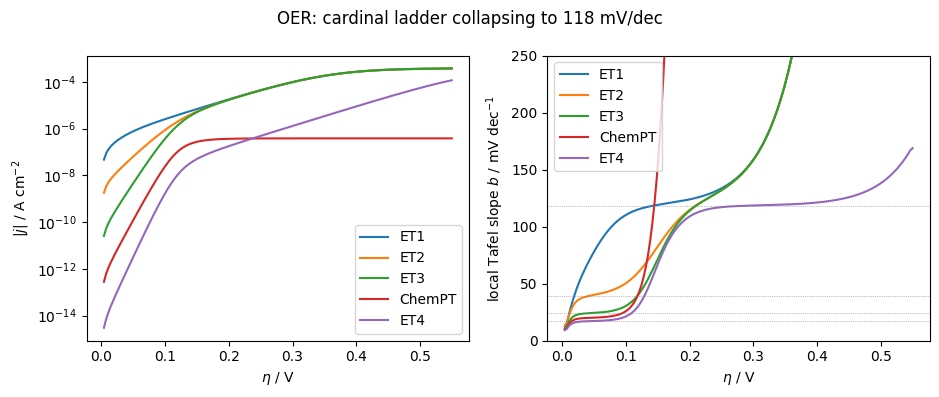

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4))
for name, (ee, jj, _, _) in cases.items():
    ax1.semilogy(ee, np.abs(jj), label=name)
    ax2.plot(ee, M.local_slope(ee, jj), label=name)
ax1.set_xlabel(r"$\eta$ / V"); ax1.set_ylabel(r"$|j|$ / A cm$^{-2}$"); ax1.legend()
ax2.set_xlabel(r"$\eta$ / V"); ax2.set_ylabel(r"local Tafel slope $b$ / mV dec$^{-1}$")
ax2.set_ylim(0, 250)
for bref in (118, 39, 24, 17):
    ax2.axhline(bref, color="gray", lw=0.5, ls=":")
ax2.legend(); fig.suptitle("OER: cardinal ladder collapsing to 118 mV/dec")
fig.tight_layout(); plt.show()

In [10]:
def slope_at(ee, jj, eta0):
    b = M.local_slope(ee, jj)
    return b[np.argmin(np.abs(ee - eta0))]

print(f"{'case':>10}{'b @ +0.06 V':>14}{'b @ +0.20 V':>14}{'b @ +0.45 V':>14}   (mV/dec)")
for name, (ee, jj, _, _) in cases.items():
    bs = [slope_at(ee, jj, e0) for e0 in (0.06, 0.20, 0.45)]
    fmt = lambda b: f"{b:10.1f}" if b < 1e3 else "     >1000"
    print(f"{name:>10}" + "".join(f"{fmt(b):>14}" for b in bs))

      case   b @ +0.06 V   b @ +0.20 V   b @ +0.45 V   (mV/dec)
       ET1          86.4         123.9         873.2
       ET2          41.2         114.6         873.7
       ET3          24.7         113.9         873.9
    ChemPT          20.5         >1000         >1000
       ET4          17.4         108.9         125.8


## Summary

Near onset the Tafel slope distinguishes the electron-transfer cases. At
intermediate overpotential four different RLS designs are slope-degenerate at
approximately 110–125 mV/dec. At high overpotential the chemical step bounds
every case. The mapping from Tafel slope to rate-limiting step is many-to-many
and moves with the measurement window. Throughout the four notebooks the three
methods agree to within their respective precision, so this
non-uniqueness reflects the kinetics of the multistep mechanisms rather than
any numerical choice.